# Deutsch-Jozsa Algorithm

In [1]:
from qiskit import QuantumCircuit
from qiskit import Aer, execute
from qiskit_ibm_provider import IBMProvider
from qiskit.providers.ibmq import least_busy
from qiskit.tools.jupyter import *
from qiskit.visualization import plot_histogram
import numpy as np
import os

# Access to IBM
IBMQ_TOKEN = os.getenv("IBMQ_TOKEN")
provider = IBMProvider(token=IBMQ_TOKEN)


## Define the oracle

In [2]:
def dj_oracle(n, case):
    qc = QuantumCircuit(n+1)

    # For "constant" case get a random output and apply a X gate on the last (y) qubit if the output is 1. 
    # Remember the effect of the oracle -> y xor f(x)
    if case == "constant":
        output = np.random.randint(2)
        if output == 1:
            qc.x(n)

    # For "balanced" case apply CNOT gates on the last (y) qubit, so for half of the inputs f(x) = 0, for the other half f(x) = 1
    # For n=2 qubit, for 00 and 11 f(x) = 0, for 01 and 10 f(x) = 1
    elif case == "balanced":
        for qubit in range(n):
            qc.cx(qubit, n)

    # Convert the oracle circuit into a gate that can be used in another circuit later
    gate = qc.to_gate()
    gate.name = "Uf"
    return gate


## Define the Deutsch-Jozsa algorithm circuit

In [4]:
def dj_algorithm(n, case = "random"):
    qc = QuantumCircuit(n+1, n)

    # Prepare the last qubit to ket(-)
    qc.x(n)
    qc.h(n) 

    # Apply Hadamard gates on the first n qubits
    for qubit in range(n):
        qc.h(qubit)

    # Define the case if case is random
    if case == "random":
        output = np.random.randint(2)
        if output == 0:
            case = "constant"
        else:
            case = "balanced"

    # Apply dj_oracle to all qubits
    qc.append(dj_oracle(n, case), range(n+1))

    # Apply again Hadamard gates to the first n qubits and measure them
    for i in range(n):
        qc.h(i)
        qc.measure(i,i)

    return qc

## Show Deutsch-Jozsa circuit

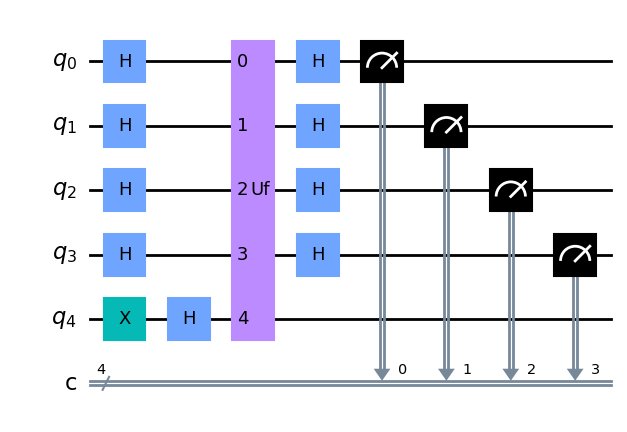

In [5]:
n = 4
qc = dj_algorithm(n)
qc.draw(output="mpl", style="clifford" )

## Execute the circuit on the local simulator

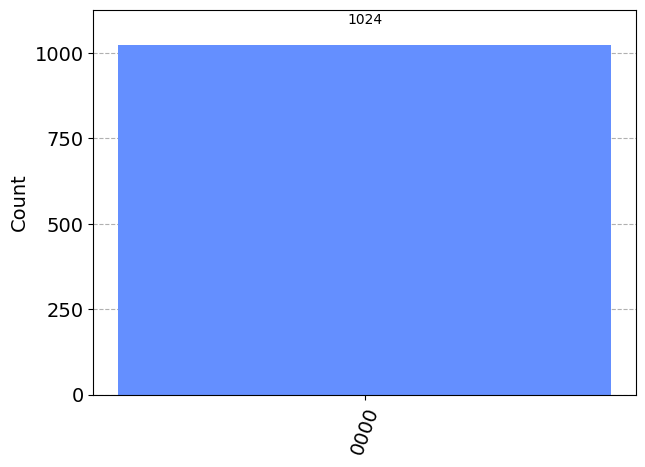

In [12]:
shots = 1024
simulator = Aer.get_backend('qasm_simulator')
qc = dj_algorithm(n, case="constant")
result = execute(qc, simulator, shots=shots).result()
counts = result.get_counts()
plot_histogram(counts)

## Execute the circuit on a IBM physical Device

In [13]:
n=4
shots=1024
# backend = least_busy(provider.backends(filters=lambda x : (x.configuration().n_qubits >= n+1 and not x.configuration().simulator and x.status().operational == True)))
backend = provider.get_backend("ibm_kyoto")
print("Least busy backend: ", backend)

qc  = dj_algorithm(n, case="balanced")
job = execute(qc, backend=backend, shots=shots, optimization_level = 3 )

Least busy backend:  <IBMBackend('ibm_kyoto')>


In [ ]:
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

## Check old submitted jobs

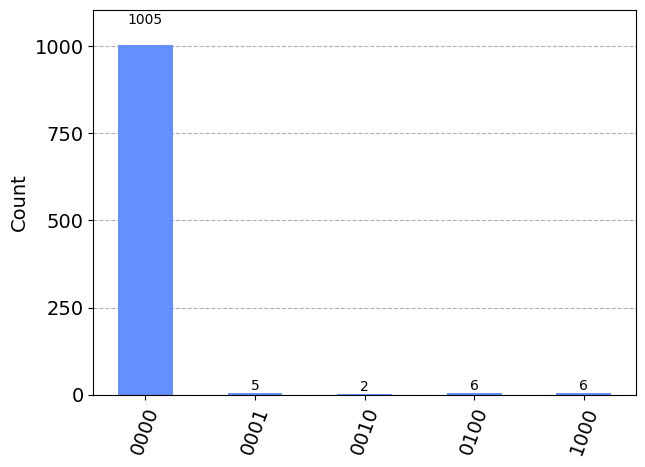

In [14]:
job1 = provider.retrieve_job("cnw2p9hvn4c0008a7f10")     # Constant case
job2 = provider.retrieve_job("cnw3dcd8ybr000847fbg")     # Balanced case

counts1 =  job1.result().get_counts()
counts2 =  job2.result().get_counts()

plot_histogram(counts1)

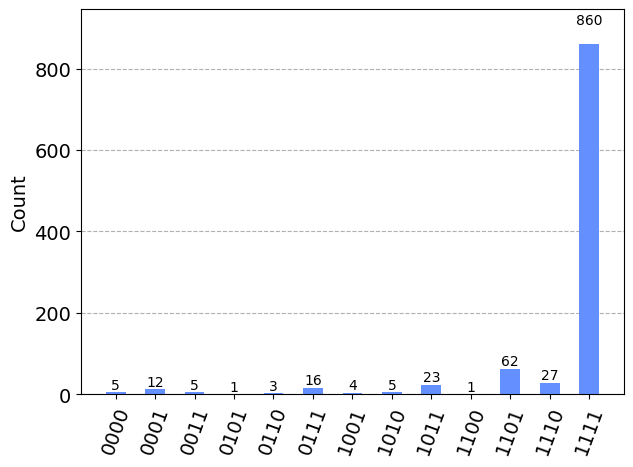

In [15]:
plot_histogram(counts2)